In [1]:
# These modules are required for the data reduction.
from dysh.fits.gbtfitsload import GBTFITSLoad
from astropy import units as u
from dysh.log import init_logging

# These modules are used for file I/O
from dysh.util.files import dysh_data
from pathlib import Path

In [2]:
init_logging(2)

# also create a local "output" directory where temporary notebook files can be stored.
output_dir = Path.cwd() / "output"
output_dir.mkdir(exist_ok=True)

In [3]:
filename = dysh_data(test="getps")

16:06:50.423 I Resolving test=getps -> AGBT05B_047_01/AGBT05B_047_01.raw.acs/


In [4]:
sdfits = GBTFITSLoad(filename)

16:06:50.529 I Index loaded from .index file (44/93 columns). Missing columns (TCAL, WCS, calibration metadata, etc.) will be automatically loaded from FITS file when first accessed.


In [5]:
sdfits.summary()

SCAN,OBJECT,VELOCITY,PROC,PROCSEQN,RESTFREQ,# IF,# POL,# INT,# FEED,AZIMUTH,ELEVATION
51,NGC5291,4386.0,OnOff,1,1.420405,1,2,11,1,198.3431,18.6427
52,NGC5291,4386.0,OnOff,2,1.420405,1,2,11,1,198.9306,18.7872
53,NGC5291,4386.0,OnOff,1,1.420405,1,2,11,1,199.3305,18.3561
54,NGC5291,4386.0,OnOff,2,1.420405,1,2,11,1,199.9157,18.4927
55,NGC5291,4386.0,OnOff,1,1.420405,1,2,11,1,200.3042,18.0575
56,NGC5291,4386.0,OnOff,2,1.420405,1,2,11,1,200.8906,18.1860
57,NGC5291,4386.0,OnOff,1,1.420405,1,2,11,1,202.3275,17.3853
58,NGC5291,4386.0,OnOff,2,1.420405,1,2,11,1,202.9192,17.4949


In [6]:
ps_scan_block = sdfits.getps(scan=51, ifnum=0, plnum=0, fdnum=0)

In [7]:
print(f"T_sys = {ps_scan_block[0].tsys.mean():.2f}")

T_sys = 19.36


In [8]:
ta = ps_scan_block.timeaverage(weights="tsys")

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


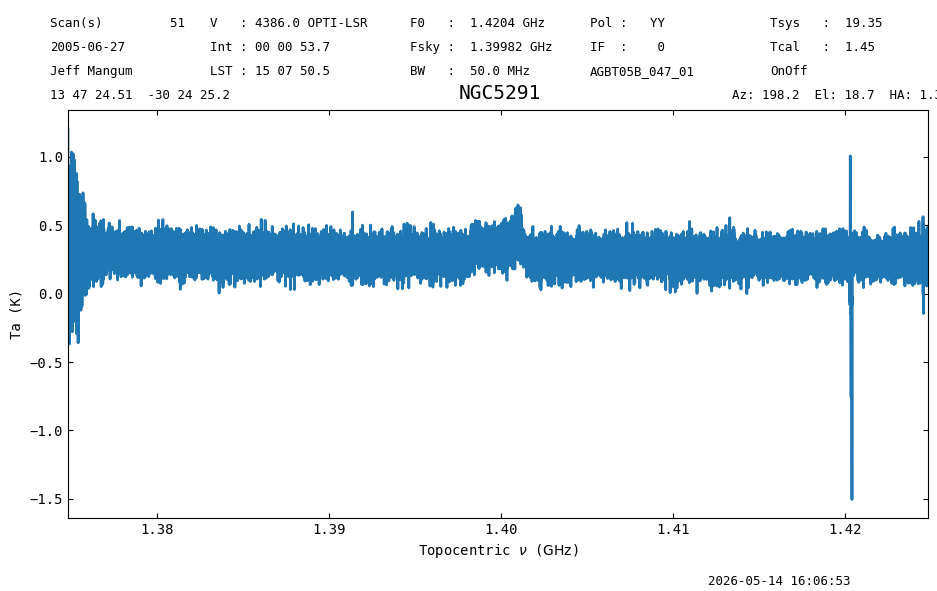

In [9]:
ta.plot();

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


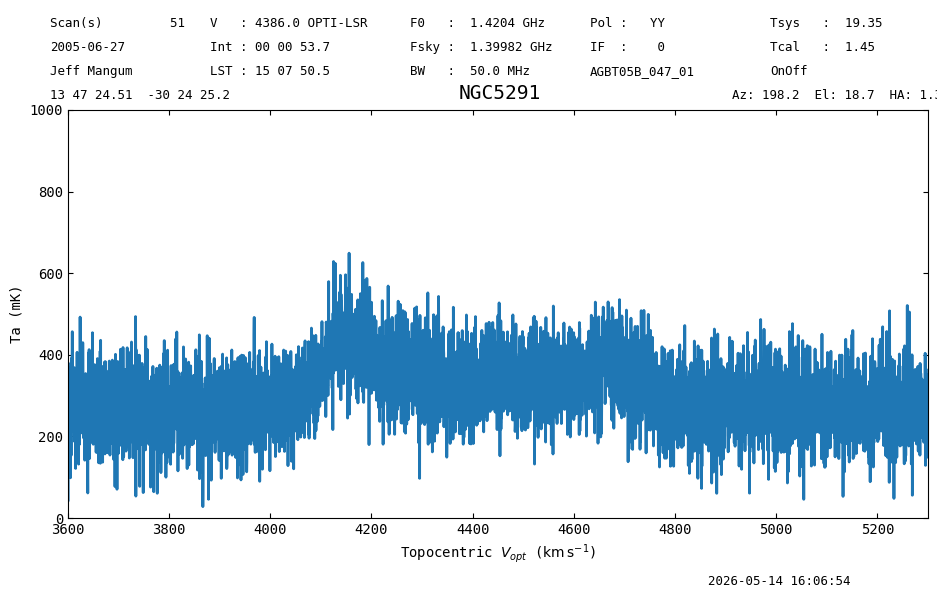

In [10]:
ta.plot(xaxis_unit="km/s", yaxis_unit="mK", ymin=0, ymax=1000, xmin=3600, xmax=5300);

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


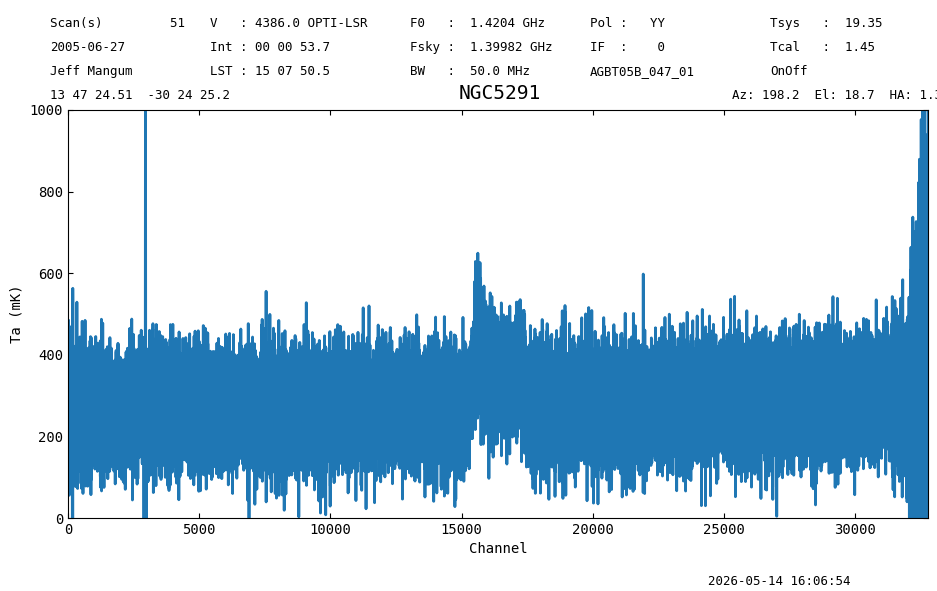

In [11]:
plt1 = ta.plot(xaxis_unit="chan", ymin=0, ymax=1000, yaxis_unit="mK")

In [12]:
kms = u.km/u.s
ta.baseline(model="poly", degree=2, exclude=[3800*kms,5000*kms]) 
#  saving the plot will also show the baseline fit
plt1.savefig(output_dir / "plt1.png")


In [13]:
ta.baseline(model="poly", degree=2, exclude=[3800*kms,5000*kms], remove=True)

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


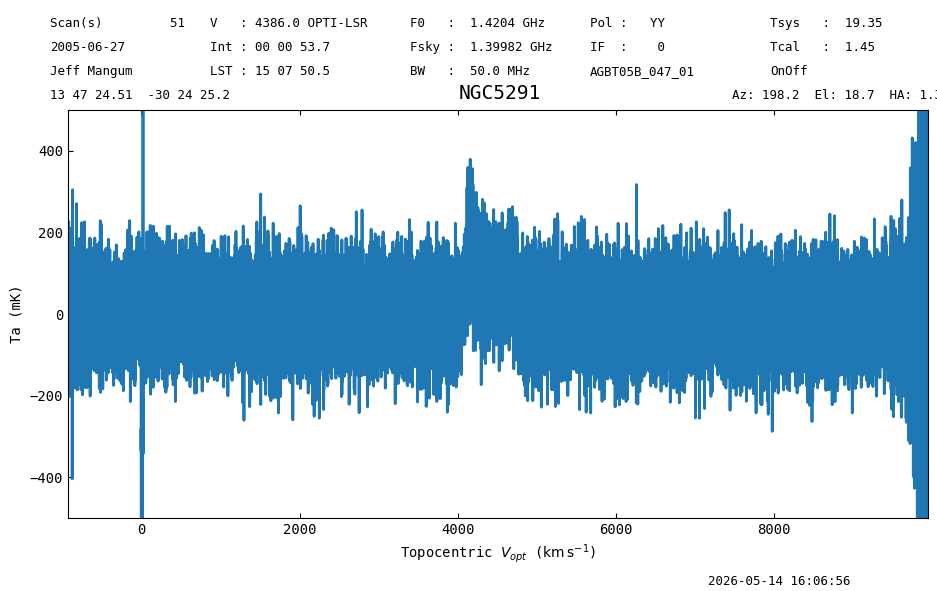

In [14]:
plt2 = ta.plot(xaxis_unit="km/s", yaxis_unit="mK", ymin=-500, ymax=500)

In [15]:
print(ta.baseline_model)

<QuantityModel Polynomial1D(2, c0=0.27098987, c1=0.02448574, c2=0.01186811, domain=(np.float64(1424816838.1210938), np.float64(1374818364.0))), input_units=Hz, return_units=K>


In [16]:
plt2.savefig(output_dir / "baselined_removed.png")

In [17]:
sdfits.select(scan=[51,52])
sdfits.selection.show()

 ID    TAG      SCAN  # SELECTED
--- --------- ------- ----------
  0 01deb38eb [51,52]         88


In [18]:
sb = sdfits.getps(plnum=0, ifnum=0, fdnum=0)

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


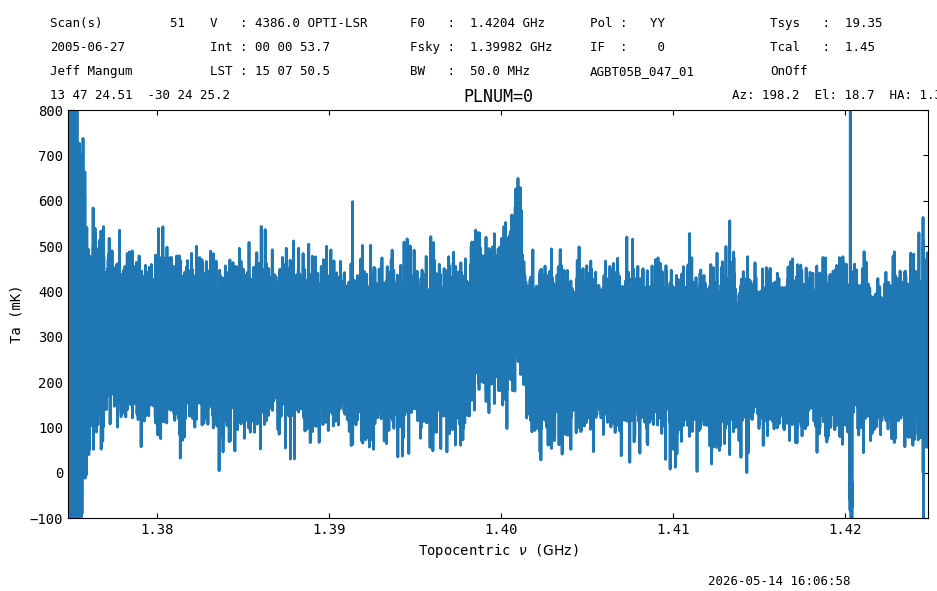

In [19]:
ta2 = sb.timeaverage(weights='tsys')
ta2.plot(xaxis_unit="GHz", ymin=-100, ymax=800, yaxis_unit="mK", title="PLNUM=0");

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


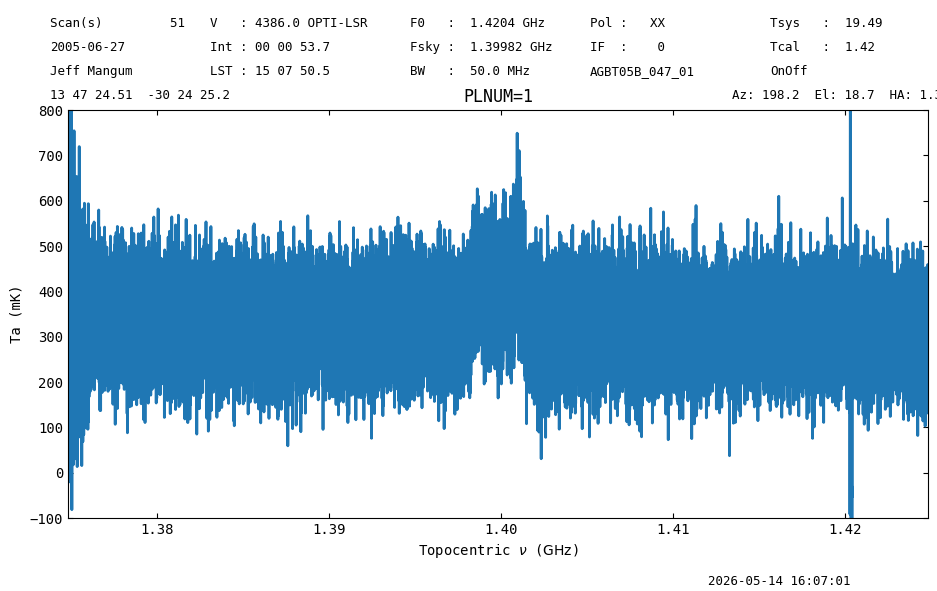

In [20]:
sb = sdfits.getps(plnum=1, fdnum=0, ifnum=0)
ta3 = sb.timeaverage(weights='tsys')
ta3.plot(xaxis_unit="GHz", ymin=-100, ymax=800, yaxis_unit="mK", title="PLNUM=1");

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


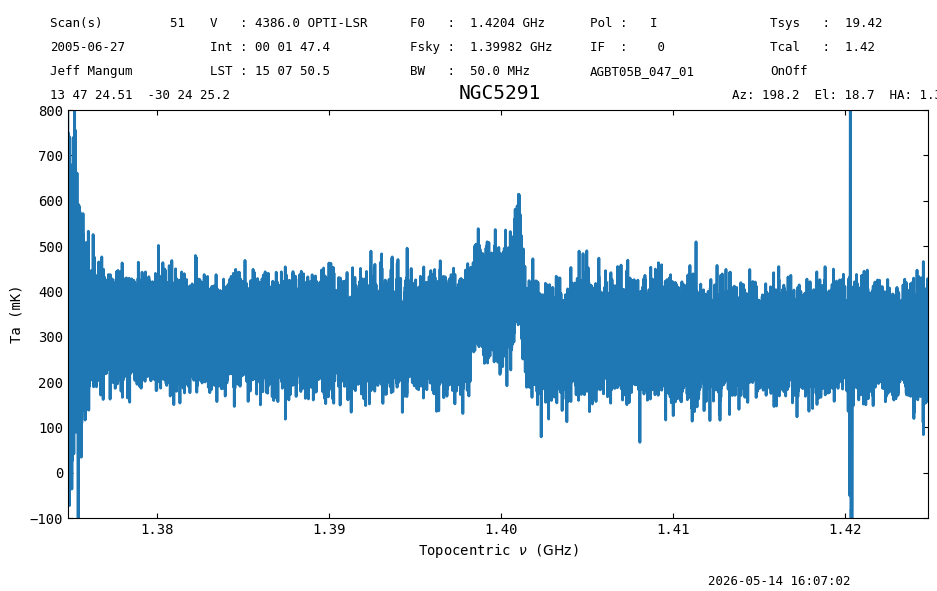

In [21]:
avg = ta2.average(ta3)
avg.plot(ymin=-100, ymax=800, yaxis_unit="mK", xaxis_unit="GHz");

In [22]:
sdfits.clear_selection()

In [23]:
ps_scan_block_0 = sdfits.getps(ifnum=0, plnum=0, fdnum=0)
ps_ta_0 = ps_scan_block_0.timeaverage(weights='tsys')
ps_ta_0.baseline(model="poly", degree=2, exclude=[3800*kms,5000*kms], remove=True)

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


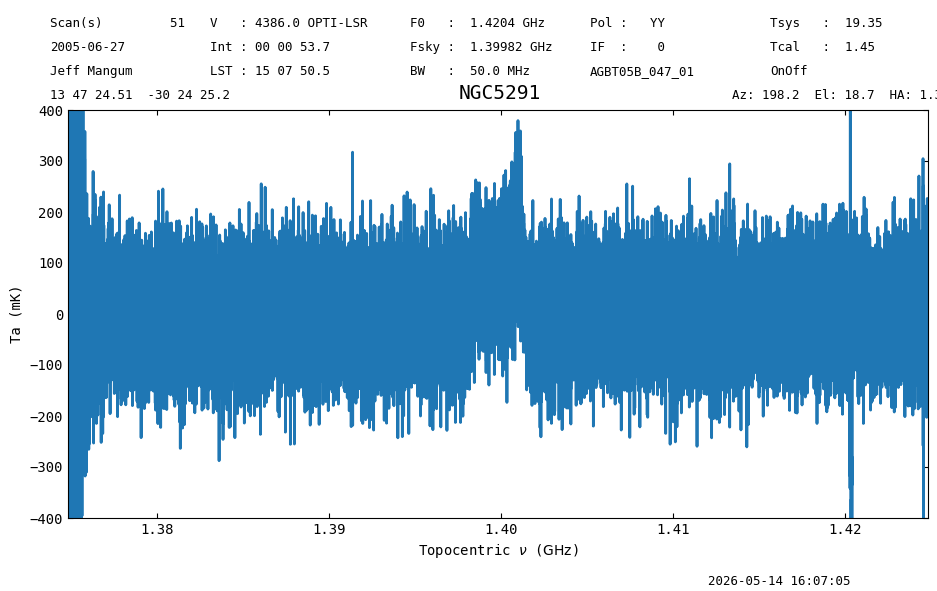

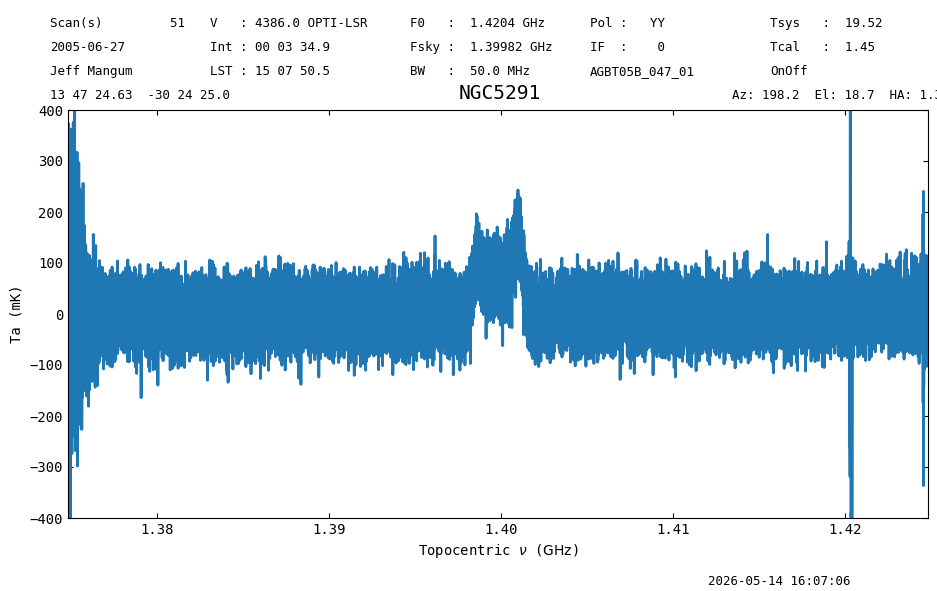

In [24]:
ta.plot(ymin=-400, ymax=400, yaxis_unit="mK", xaxis_unit="GHz")
ps_ta_0.plot(ymin=-400, ymax=400, yaxis_unit="mK", xaxis_unit="GHz");

In [25]:
ps_ta_0.check_stats(0.06010087 * u.K)

16:07:07.133 I rms is OK 
